# 🐼 Pandas 3-Hour Workout — Exercises Only

*Generated on 2025-09-01 15:06*

This notebook mirrors the 3-hour plan but contains **exercises only**. Fill in each cell where marked with `# TODO`.

**Structure:**
1) Warmup (Titanic)
2) Time Series (Stocks via `yfinance`)
3) Clean & Analyze (Flights)
4) Mini-Project (Merging, returns, correlation)


## 0. Setup
Install and import anything you need. Configure pandas display if you like.


In [1]:
# TODO: import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns (optional)
# TODO: (optional) set pandas display options

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set pandas display options (optional)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.expand_frame_repr', False)
# pd.set_option('display.max_rows', 100)
# pd.set_option('display.float_format', lambda x: '%.3f' % x)


pd.set_option('display.max_columns', 10)



## 1) Warmup (Titanic) — 30 min

**Dataset:** `seaborn.load_dataset("titanic")`

**Tasks:**
1. Load Titanic into a DataFrame and show `shape`, `head()`, and `info()`.
2. Count missing values per column.
3. Fill `age` with the median and drop rows with missing `embarked`.
4. Create `family_size = sibsp + parch + 1` and `is_child = age < 12`.
5. Compute survival rate by `sex` and by `class`.
6. Build a pivot table of **mean fare** by `sex` (rows) and `class` (columns).
7. **Advanced:** Compute survival rate for `who` (child/woman/man) and sort descending.
8. **Bonus:** Plot survival rate vs `family_size`.


In [2]:
# TODO: Load Titanic (hint: sns.load_dataset("titanic"))
titanic = sns.load_dataset('titanic')

In [3]:
# # TODO: Show shape, head, info
titanic_shape = titanic.shape
titanic_head = titanic.head(5)
titanic_info = titanic.info()

print(titanic_shape)
print(titanic_head)
print(titanic_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
(891, 15)
   survived  pclass     sex   age  sibsp  ...  adult_male  deck  emba

In [4]:
# TODO: Missing values per column
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# TODO: Fill age with median; drop rows where embarked is NA
# 
# titanic.fillna(titanic.age.median(),inplace=True)

titanic.age = titanic.age.fillna(titanic.age.median())

In [6]:
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic.dropna(subset=['embarked'],inplace=True)
titanic.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

In [8]:
# TODO: Create family_size and is_child
titanic.info()
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_child'] = titanic.age < 18

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  deck         201 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        889 non-null    object  
 14  alone        889 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 87.3+ KB


In [9]:
titanic.head(1)

,survived,pclass,sex,age,sibsp,...,embark_town,alive,alone,family_size,is_child
0,0,3,male,22.0,1,...,Southampton,no,False,2,False


In [10]:
# TODO: Survival rate by sex and by class
# pd.crosstab(index=titanic['sex'],columns=titanic['class'],values=titanic['survived'],aggfunc='mean').round(2)
pd.crosstab(index=titanic['sex'],columns=titanic['class'],values=titanic['survived'],aggfunc='mean').round(2)

class,First,Second,Third
sex,,,
female,0.97,0.92,0.50
male,0.37,0.16,0.14


In [11]:
# TODO: Pivot table of mean fare by sex (rows) and class (cols)
pd.pivot_table(data=titanic,index='sex',columns='class',values='fare',aggfunc='mean').round(2)



/var/folders/c9/whb3jh8n0sz1zw9tjll5y44r0000gn/T/ipykernel_39389/674758459.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(data=titanic,index='sex',columns='class',values='fare',aggfunc='mean').round(2)


class,First,Second,Third
sex,,,
female,106.69,21.97,16.12
male,67.23,19.74,12.66


In [12]:
# TODO (Advanced): Survival rate for 'who' categories, sorted
survival_rate = pd.DataFrame(
    {
    'total' : titanic.groupby('who')['survived'].count(),
    'survived_count' : titanic.groupby('who')['survived'].sum()
    # 'survival_rate' = titanic.groupby('who')['survived'].count()

    }
)

In [13]:
survival_rate = survival_rate.reset_index()

In [14]:
survival_rate['rate']= survival_rate['survived_count']/survival_rate['total']

In [15]:
survival_rate

,who,total,survived_count,rate
0,child,83,49,0.590361
1,man,537,88,0.163873
2,woman,269,203,0.754647


In [16]:
# TODO (Bonus): Plot survival rate vs family_size (matplotlib; separate figure)
family_size_survival = titanic.groupby('family_size')['survived'].mean()

In [17]:
family_size_survival = family_size_survival.reset_index()

In [18]:
family_size_survival

,family_size,survived
0,1,0.300935
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


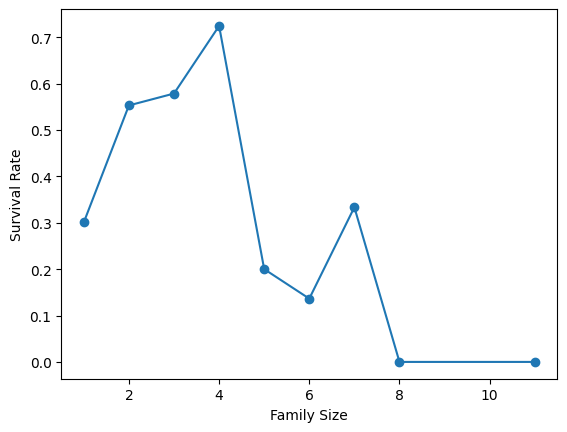

In [19]:

plt.plot(family_size_survival['family_size'],family_size_survival['survived'],marker='o')

plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

## 2) Time Series (Stocks via `yfinance`) — 60 min

**Tasks:**
1. Download OHLCV for tickers (e.g., `AAPL MSFT TSLA`) from 2020-01-01 to 2024-12-31.
2. Create a **Close-only** wide DataFrame where columns are tickers.
3. Compute **daily returns** with `pct_change()`.
4. Plot a **30-day moving average** for AAPL close.
5. Resample to **monthly returns** (end of month).
6. Find which ticker had the **best return** in calendar year 2022.

> If `yfinance` is missing, install it first.


In [20]:
# TODO: import yfinance as yf (install if needed)
# !pip install yfinance
import yfinance as yf
pd.set_option('display.max_columns',None)

/Users/vaibhav/anaconda3/envs/my_quant_lab/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [21]:
# TODO: Download multi-ticker price data (auto_adjust=True recommended)
tickers = ("AAPL MSFT TSLA")

prices = yf.download(tickers, start = "2020-01-01", end = "2024-12-31")
prices.head()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


Price           Close                              High              \
Ticker           AAPL        MSFT       TSLA       AAPL        MSFT   
Date                                                                  
2020-01-02  72.538521  152.791138  28.684000  72.598899  152.895777   
2020-01-03  71.833275  150.888626  29.534000  72.594040  152.153802   
2020-01-06  72.405678  151.278641  30.102667  72.444321  151.345236   
2020-01-07  72.065140  149.899323  31.270666  72.671333  151.887449   
2020-01-08  73.224396  152.286926  32.809334  73.526287  152.962326   

Price                        Low                              Open  \
Ticker           TSLA       AAPL        MSFT       TSLA       AAPL   
Date                                                                 
2020-01-02  28.713333  71.292311  150.612762  28.114000  71.545897   
2020-01-03  30.266666  71.608669  150.355924  29.128000  71.765651   
2020-01-06  30.104000  70.703012  148.881465  29.333332  70.954188   
2020-01-07  31.441999  71.845362  149.652001  30.224001  72.415330   
2020-01-08  33.232666  71.768071  150.251234  31.215334  71.768071   

Price                                 Volume                       
Ticker            MSFT       TSLA       AAPL      MSFT       TSLA  
Date                                                               
2020-01-02  151.040826  28.299999  135480400  22622100  142981500  
2020-01-03  150.603260  29.366667  146322800  21116200  266677500  
2020-01-06  149.423690  29.364668  118387200  20813700  151995000  
2020-01-07  151.554518  30.760000  108872000  21634100  268231500  
2020-01-08  151.183463  31.580000  132079200  27746500  467164500

In [22]:
# TODO: Build Close-only wide DataFrame
prices.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'TSLA'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (  'High', 'TSLA'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (   'Low', 'TSLA'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            (  'Open', 'TSLA'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [23]:
close_wide = prices.Close.copy()

close_wide.head(5)

Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-02,72.538521,152.791138,28.684000
2020-01-03,71.833275,150.888626,29.534000
2020-01-06,72.405678,151.278641,30.102667
2020-01-07,72.065140,149.899323,31.270666
2020-01-08,73.224396,152.286926,32.809334


In [24]:
# TODO: Compute daily returns and preview
daily_Return=close_wide.pct_change().dropna()
daily_Return.head(10)
# --1257
# 1256

Ticker,AAPL,MSFT,TSLA
Date,,,
2020-01-03,-0.009722,-0.012452,0.029633
2020-01-06,0.007968,0.002585,0.019255
2020-01-07,-0.004703,-0.009118,0.038801
2020-01-08,0.016086,0.015928,0.049205
2020-01-09,0.021241,0.012493,-0.021945
2020-01-10,0.002260,-0.004627,-0.006627
2020-01-13,0.021365,0.012025,0.097689
2020-01-14,-0.013503,-0.007043,0.024883
2020-01-15,-0.004286,0.006476,-0.036102


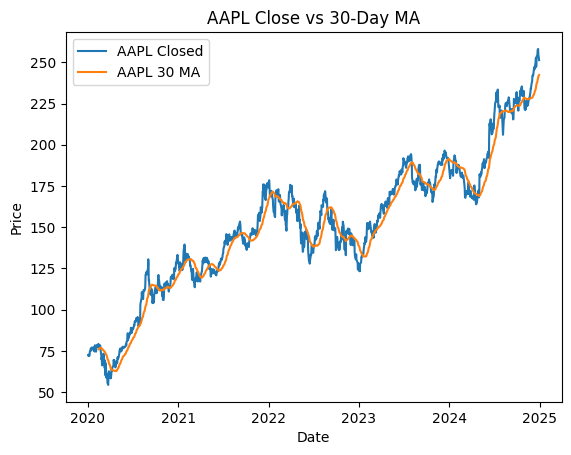

In [25]:
# TODO: Plot AAPL 30-day moving average (create a separate figure)


ma30 =  close_wide['AAPL'].rolling(window=30).mean()
plt.figure()
plt.plot(close_wide.index,close_wide['AAPL'],label='AAPL Closed')
plt.plot(ma30.index, ma30, label='AAPL 30 MA')
plt.legend()
plt.title("AAPL Close vs 30-Day MA")
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [26]:
# TODO: Resample to monthly returns (end-of-month) and preview
monthly_prices = close_wide.resample("M").last()
monthly_ret = monthly_prices.pct_change().dropna()
monthly_ret.head(5)

/var/folders/c9/whb3jh8n0sz1zw9tjll5y44r0000gn/T/ipykernel_39389/1180540988.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = close_wide.resample("M").last()


Ticker,AAPL,MSFT,TSLA
Date,,,
2020-02-29,-0.114702,-0.045688,0.026776
2020-03-31,-0.069761,-0.026541,-0.215557
2020-04-30,0.155374,0.136326,0.492137
2020-05-31,0.085094,0.025391,0.067939
2020-06-30,0.147386,0.110559,0.293186


In [27]:
close_wide.index.year

Index([2020, 2020, 2020, 2020, 2020, 2020, 2020, 2020, 2020, 2020,
       ...
       2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024],
      dtype='int32', name='Date', length=1257)

In [28]:
# TODO: Identify the best-performing ticker in 2022 (full-year return)
# yr = 2022
# r_2022 = ( close_wide[close_wide.index.year == yr])
           
# # close_wide.index.year == yr
# price_month_end = r_2022.resample("M").last()
# price_month_end.pct_change().dropna()


yr = 2022
r_2022 = (close_wide[close_wide.index.year == yr]
          .pipe(lambda df: df.iloc[-1] / df.iloc[0] - 1))
r_2022.sort_values(ascending=False)

/var/folders/c9/whb3jh8n0sz1zw9tjll5y44r0000gn/T/ipykernel_39389/3856735067.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  price_month_end = r_2022.resample("M").last()


Ticker,AAPL,MSFT,TSLA
Date,,,
2022-02-28,-0.054066,-0.037212,-0.070768
2022-03-31,0.057473,0.031862,0.238009
2022-04-30,-0.097131,-0.099867,-0.191945
2022-05-31,-0.054496,-0.018077,-0.129197
2022-06-30,-0.081430,-0.055321,-0.111888
2022-07-31,0.188634,0.093097,0.323765
2022-08-31,-0.031208,-0.066663,-0.072489
2022-09-30,-0.120977,-0.109267,-0.037589
2022-10-31,0.109551,-0.003306,-0.142168


## 3) Clean & Analyze (Flights) — 60 min

**Tasks:**
1. Load `flights` from seaborn and preview it.
2. Create a proper `datetime` column from `year` and `month`, set as index, and sort.
3. Pivot passengers by `year` (rows) and `month` (columns).
4. Compute a 12-month rolling average of `passengers` and plot it alongside the original series.
5. Find the **busiest year** by total passengers.


In [29]:
# TODO: Load flights and preview


In [30]:
# TODO: Create datetime index from year/month and sort


In [31]:
# TODO: Pivot passengers by year x month


In [32]:
# TODO: 12-month rolling average plot (create a separate figure)


In [33]:
# TODO: Busiest year by total passengers


## 4) Mini-Project (30 min): Merge, Analyze, Visualize

**Objective:**
- Combine multiple tickers, compute returns, and analyze correlation.

**Tasks:**
1. Using the Close-only DataFrame, compute **monthly returns** for your tickers.
2. Build a **correlation matrix** of monthly returns.
3. Plot the correlation matrix as a heatmap (matplotlib). No seaborn styles or colors required.
4. (Bonus) Identify the pair with the **highest correlation** and the pair with the **lowest correlation**.


In [34]:
# TODO: Compute monthly returns from Close-only prices


In [35]:
# TODO: Correlation matrix of monthly returns


In [36]:
# TODO: Heatmap of correlation (matplotlib; separate figure)


In [37]:
# TODO (Bonus): Most and least correlated ticker pairs


In [38]:
dat = yf.Tickers("MSFT")
# dat.info
# dat.calendar['Revenue High']
# dat.analyst_price_targets
# dat.quarterly_income_stmt
dat.history(period='1mo')
# dat.option_chain(dat.options[0]).calls

[*********************100%***********************]  1 of 1 completed


Price,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,,
2025-08-06,524.078491,0.00,530.827407,523.170011,530.028732,0.0,21355700
2025-08-07,519.985229,0.00,527.223331,516.700590,525.935409,0.0,16079100
2025-08-08,521.183228,0.00,523.798923,518.557539,521.742306,0.0,15531000
2025-08-11,520.913696,0.00,526.724152,518.867012,521.442795,0.0,20194400
2025-08-12,528.371399,0.00,530.108533,521.842154,522.890419,0.0,18667000
2025-08-13,519.725647,0.00,531.825751,518.517611,531.236692,0.0,19619200
2025-08-14,521.622498,0.00,525.086834,519.286372,521.702383,0.0,20269100
2025-08-15,519.316284,0.00,525.236545,518.228107,521.912054,0.0,25213300
